# [LAB11] 지도학습 > 시계열 분석 > Prophet (하이퍼파라미터 튜닝)

## 📘 #01. 준비작업

### 📝 [1] 패키지 참조

### 📝 [2] 데이터셋 가져오기

In [1]:
from hossam import *
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from pandas import to_datetime, DataFrame, DatetimeIndex, Series, date_range, concat
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
# 로딩바
from tqdm.auto import tqdm

In [2]:
origin = load_data("covid19_seoul_230531")
origin.head()

2020년 2월 5일부터 2023년 5월 31일까지 서울의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)


,서울시 기준일,서울시 확진자,서울시 추가 확진,서울시 치료중,서울시 퇴원,서울시 추가 퇴원,서울시 사망,서울시 의심환자 전체,서울시 의심환자 검사중,서울시 의심환자 검사결과(음성),전국 기준일,전국 확진,전국 추가 확진,전국 치료중,전국 퇴원,전국 사망,전국 의심환자 전체,전국 의심환자 검사중,전국 의심환자 검사결과(음성),자가격리자 해외입국자 감시중,자가격리자 해외입국자 감시해제,자가격리자 접촉자 감시중,자가격리자 접촉자 감시해제,확인중 확진자,서울시 당일사망자,전국 당일 사망자
0,2023-05-31,6204277,5987.000,0,NaN,NaN,6492,NaN,NaN,NaN,2023.05.31.00,31703511.000,24411.000,0,NaN,34784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,6.000,17.000
1,2023-05-30,6198290,3326.000,0,NaN,NaN,6486,NaN,NaN,NaN,2023.05.30.00,31679100.000,13529.000,0,NaN,34767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,7.000
2,2023-05-29,6194964,1393.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.29.00,31665571.000,6868.000,0,NaN,34760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,3.000
3,2023-05-28,6194964,1393.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.28.00,31665571.000,6868.000,0,NaN,34760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,1.000,3.000
4,2023-05-27,6191196,4078.000,0,NaN,NaN,6485,NaN,NaN,NaN,2023.05.27.00,31647238.000,17796.000,0,NaN,34784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,3.000


2020년 2월 5일부터 2023년 5월 31일까지 서울의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)

### 📝 [3] 데이터 전처리

- 필요한 데이터만 추출
- 결측치 확인
- 결측치 처리 (해당 날짜에 확진자가 발생하지 않은 것으로 보고 0으로 채움, 서울시 기준)

### ✏ 날짜 타입에 대한 형변환

In [3]:
df = origin[['서울시 기준일', '서울시 추가 확진']].copy()
df.head()

,서울시 기준일,서울시 추가 확진
0,2023-05-31,5987.000
1,2023-05-30,3326.000
2,2023-05-29,1393.000
3,2023-05-28,1393.000
4,2023-05-27,4078.000


In [4]:
df.isna().sum()

서울시 기준일      0
서울시 추가 확진    1
dtype: int64

In [5]:
df2 = df.fillna(0)
df2.isna().sum()

서울시 기준일      0
서울시 추가 확진    0
dtype: int64

In [6]:
df2['서울시 기준일'] = to_datetime(df2['서울시 기준일'].str.strip(), format="%Y-%m-%d")
df2.dtypes

서울시 기준일      datetime64[ns]
서울시 추가 확진           float64
dtype: object

### 📝 [4] 컬럼이름 변경, 정렬, 인덱스 재설정

### 📝 [5] 훈련, 검증 데이터 분리

In [7]:
df3 = df2.rename(columns={"서울시 기준일": "ds", "서울시 추가 확진": "y"})
df3.sort_values('ds', inplace=True)
df3.reset_index(drop=True, inplace=True)
df3.head()

,ds,y
0,2020-02-05,0.000
1,2020-02-06,0.000
2,2020-02-07,0.000
3,2020-02-08,0.000
4,2020-02-09,0.000


In [8]:
# 분할 비율
split_ratio = 0.8
# 분할 인덱스
split_idx = int(len(df3) * split_ratio)
# 훈련 / 검증 데이터
train = df3.iloc[:split_idx]
test = df3.iloc[split_idx:]

In [9]:
print("Train 기간:", train['ds'].min(), "~", train['ds'].max())
print("Valid 기간:", test['ds'].min(), "~", test['ds'].max())

Train 기간: 2020-02-05 00:00:00 ~ 2022-09-30 00:00:00
Valid 기간: 2022-10-01 00:00:00 ~ 2023-05-31 00:00:00


### 📝 [7] 휴일 데이터 생성

- ✏ 주말
- ✏ 한국 기준 공휴일

In [10]:
start_date = train['ds'].min()
end_date = test['ds'].max()
sat = date_range(start=start_date, end=end_date, freq='W-SAT')
sun = date_range(start=start_date, end=end_date, freq='W-SUN')
weekend = sat.union(sun)
df_weekend = DataFrame({"holiday": "weekend", "ds": weekend.sort_values(),
                        "lower_window": 0, "upper_window": 0})
df_weekend.head()

,holiday,ds,lower_window,upper_window
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


In [11]:
# 기간에 포함되는 연도 자동 추출
years = list(range(to_datetime(start_date).year, to_datetime(end_date).year + 1))
# 한국 공휴일 객체 생성
kr = holidays.KR(years=years)
kr

{datetime.date(2020, 1, 1): '신정연휴', datetime.date(2020, 1, 25): '설날', datetime.date(2020, 1, 24): '설날 전날', datetime.date(2020, 1, 26): '설날 다음날', datetime.date(2020, 3, 1): '삼일절', datetime.date(2020, 4, 30): '부처님오신날', datetime.date(2020, 5, 5): '어린이날', datetime.date(2020, 6, 6): '현충일', datetime.date(2020, 8, 15): '광복절', datetime.date(2020, 10, 3): '개천절', datetime.date(2020, 10, 9): '한글날', datetime.date(2020, 10, 1): '추석', datetime.date(2020, 9, 30): '추석 전날', datetime.date(2020, 10, 2): '추석 다음날', datetime.date(2020, 12, 25): '기독탄신일', datetime.date(2020, 4, 15): '국회의원 선거일', datetime.date(2020, 1, 27): '설날 대체 휴일', datetime.date(2020, 8, 17): '임시공휴일', datetime.date(2021, 1, 1): '신정연휴', datetime.date(2021, 2, 12): '설날', datetime.date(2021, 2, 11): '설날 전날', datetime.date(2021, 2, 13): '설날 다음날', datetime.date(2021, 3, 1): '삼일절', datetime.date(2021, 5, 19): '부처님오신날', datetime.date(2021, 5, 5): '어린이날', datetime.date(2021, 6, 6): '현충일', datetime.date(2021, 8, 15): '광복절', datetime.date(2021, 10, 3

In [12]:
holidays_dict = {"holiday": [], "ds": [], "lower_window": [], "upper_window": []}
for date, name in kr.items():
    holidays_dict["holiday"].append(name)
    holidays_dict["ds"].append(date)
    holidays_dict["lower_window"].append(0)
    holidays_dict["upper_window"].append(0)
df_holidays = DataFrame(holidays_dict)
df_holidays['ds'] = to_datetime(df_holidays['ds'])
df_holidays.sort_values('ds', inplace=True)
df_holidays.head()

,holiday,ds,lower_window,upper_window
0,신정연휴,2020-01-01,0,0
2,설날 전날,2020-01-24,0,0
1,설날,2020-01-25,0,0
3,설날 다음날,2020-01-26,0,0
16,설날 대체 휴일,2020-01-27,0,0


연휴까지 적용되어 있으므로 lower, upper window 설정 필요 없음

### 📝 주말과 공휴일 병합

### ✏ 학습 기간에 포함되는 데이터만 필터링

In [13]:
holydays_final = concat([df_weekend, df_holidays], ignore_index=True)
holydays_final.sort_values('ds', inplace=True)
holydays_final.head(10)

,holiday,ds,lower_window,upper_window
346,신정연휴,2020-01-01,0,0
347,설날 전날,2020-01-24,0,0
348,설날,2020-01-25,0,0
349,설날 다음날,2020-01-26,0,0
350,설날 대체 휴일,2020-01-27,0,0
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


In [14]:
mask = (holydays_final['ds'] >= start_date) & (holydays_final['ds'] <= end_date)
holyday_final = holydays_final.loc[mask].reset_index(drop=True)
holyday_final.head()

,holiday,ds,lower_window,upper_window
0,weekend,2020-02-08,0,0
1,weekend,2020-02-09,0,0
2,weekend,2020-02-15,0,0
3,weekend,2020-02-16,0,0
4,weekend,2020-02-22,0,0


## 📘 #02. Prophet 모델 구현

### 📝 [1] 튜닝하고자 하는 하이퍼파라미터 정의

### 📝 [2] GridSearchCV 구성

In [15]:
params = ParameterGrid({
    'growth': ['linear'],
    'changepoint_prior_scale': [0.01, 0.1, 1.0],   # <-- 튜닝 대상
    'seasonality_mode': ['additive', 'multiplicative'],  # <-- 튜닝 대상
    'yearly_seasonality': [True],
    'weekly_seasonality': [True],
    'daily_seasonality': [False],
    'holidays': [holyday_final]
})
print('Total Possible Models', len(params))

Total Possible Models 6


In [16]:
%%time
import logging
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
result = []
with tqdm(total=len(params)) as pbar:
    for i, p in enumerate(params):
        pbar.set_description(f"Model {i+1}/{len(params)}")
        m = Prophet(**p)
        m.fit(train)
        future = m.make_future_dataframe(periods=len(test), freq='D')
        forecast = m.predict(future)
        pred = forecast[['ds', 'yhat']][-len(test):]
        score = np.sqrt(mean_squared_error(test['y'].values, pred['yhat'].values))
        result.append({
            "score": score,
            "model": m,
            "params": p,
        })
        pbar.update(1)

  0%|          | 0/6 [00:00<?, ?it/s]

13:02:06 - cmdstanpy - INFO - Chain [1] start processing
13:02:06 - cmdstanpy - INFO - Chain [1] done processing
13:02:07 - cmdstanpy - INFO - Chain [1] start processing
13:02:07 - cmdstanpy - INFO - Chain [1] done processing
13:02:07 - cmdstanpy - INFO - Chain [1] start processing
13:02:07 - cmdstanpy - INFO - Chain [1] done processing
13:02:08 - cmdstanpy - INFO - Chain [1] start processing
13:02:08 - cmdstanpy - INFO - Chain [1] done processing
13:02:08 - cmdstanpy - INFO - Chain [1] start processing
13:02:09 - cmdstanpy - INFO - Chain [1] done processing
13:02:09 - cmdstanpy - INFO - Chain [1] start processing
13:02:10 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 1.78 s
Wall time: 3.99 s


In [17]:
# result 배열에서 score가 가장 좋은 모델을 찾는다.
# RMSE가 가장 낮은 모델이 가장 좋은 모델이므로, score가 가장 작은 모델을 찾는다.
best_index = min(result, key=lambda x: x['score'])
best_model = best_index['model']
best_params = best_index['params']
best_score = best_index['score']
print("Best Score (RMSE):", best_score)
print("Best Parameters:", best_params)

Best Score (RMSE): 11830.479594665558
Best Parameters: {'changepoint_prior_scale': 0.1, 'daily_seasonality': False, 'growth': 'linear', 'holidays':           holiday         ds  lower_window  upper_window
0         weekend 2020-02-08             0             0
1         weekend 2020-02-09             0             0
2         weekend 2020-02-15             0             0
3         weekend 2020-02-16             0             0
4         weekend 2020-02-22             0             0
..            ...        ...           ...           ...
400       weekend 2023-05-21             0             0
401       weekend 2023-05-27             0             0
402        부처님오신날 2023-05-27             0             0
403       weekend 2023-05-28             0             0
404  부처님오신날 대체 휴일 2023-05-29             0             0

[405 rows x 4 columns], 'seasonality_mode': 'additive', 'weekly_seasonality': True, 'yearly_seasonality': True}


## 📘 #03. 학습 결과 확인

### 📝 [1] 예측 데이터 생성

In [18]:
# 실제 예측 데이터보다 7단계 더 미래까지 예측해보자.(1주일)
future = best_model.make_future_dataframe(periods=len(test)+7, freq='D')
forecast = best_model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,holidays,holidays_lower,holidays_upper,weekend,weekend_lower,weekend_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,개천절,개천절_lower,개천절_upper,개천절 대체 휴일,개천절 대체 휴일_lower,개천절 대체 휴일_upper,광복절,광복절_lower,광복절_upper,광복절 대체 휴일,광복절 대체 휴일_lower,광복절 대체 휴일_upper,국회의원 선거일,국회의원 선거일_lower,국회의원 선거일_upper,기독탄신일,기독탄신일_lower,기독탄신일_upper,대통령 선거일,대통령 선거일_lower,대통령 선거일_upper,부처님오신날,부처님오신날_lower,부처님오신날_upper,부처님오신날 대체 휴일,부처님오신날 대체 휴일_lower,부처님오신날 대체 휴일_upper,삼일절,삼일절_lower,삼일절_upper,설날,설날_lower,설날_upper,설날 다음날,설날 다음날_lower,설날 다음날_upper,설날 대체 휴일,설날 대체 휴일_lower,설날 대체 휴일_upper,설날 전날,설날 전날_lower,설날 전날_upper,신정연휴,신정연휴_lower,신정연휴_upper,어린이날,어린이날_lower,어린이날_upper,임시공휴일,임시공휴일_lower,임시공휴일_upper,지방선거일,지방선거일_lower,지방선거일_upper,추석,추석_lower,추석_upper,추석 다음날,추석 다음날_lower,추석 다음날_upper,추석 대체 휴일,추석 대체 휴일_lower,추석 대체 휴일_upper,추석 전날,추석 전날_lower,추석 전날_upper,한글날,한글날_lower,한글날_upper,한글날 대체 휴일,한글날 대체 휴일_lower,한글날 대체 휴일_upper,현충일,현충일_lower,현충일_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-02-05,-19645.796,-19079.924,-2493.571,-19645.796,-19645.796,8825.631,8825.631,8825.631,0.000,0.000,0.000,0.000,0.000,0.000,-2.078,-2.078,-2.078,8827.710,8827.710,8827.710,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-10820.165
1,2020-02-06,-19390.048,-19426.846,-1973.988,-19390.048,-19390.048,8767.400,8767.400,8767.400,0.000,0.000,0.000,0.000,0.000,0.000,-359.579,-359.579,-359.579,9126.979,9126.979,9126.979,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-10622.647
2,2020-02-07,-19134.299,-19126.228,-2531.999,-19134.299,-19134.299,8418.826,8418.826,8418.826,0.000,0.000,0.000,0.000,0.000,0.000,-998.923,-998.923,-998.923,9417.749,9417.749,9417.749,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-10715.473
3,2020-02-08,-18878.551,-18515.907,-2778.188,-18878.551,-18878.551,8684.507,8684.507,8684.507,-4152.341,-4152.341,-4152.341,-4152.341,-4152.341,-4152.341,3138.113,3138.113,3138.113,9698.735,9698.735,9698.735,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-10194.044
4,2020-02-09,-18622.802,-17875.171,-1620.688,-18622.802,-18622.802,8312.131,8312.131,8312.131,-4152.341,-4152.341,-4152.341,-4152.341,-4152.341,-4152.341,2495.212,2495.212,2495.212,9969.260,9969.260,99

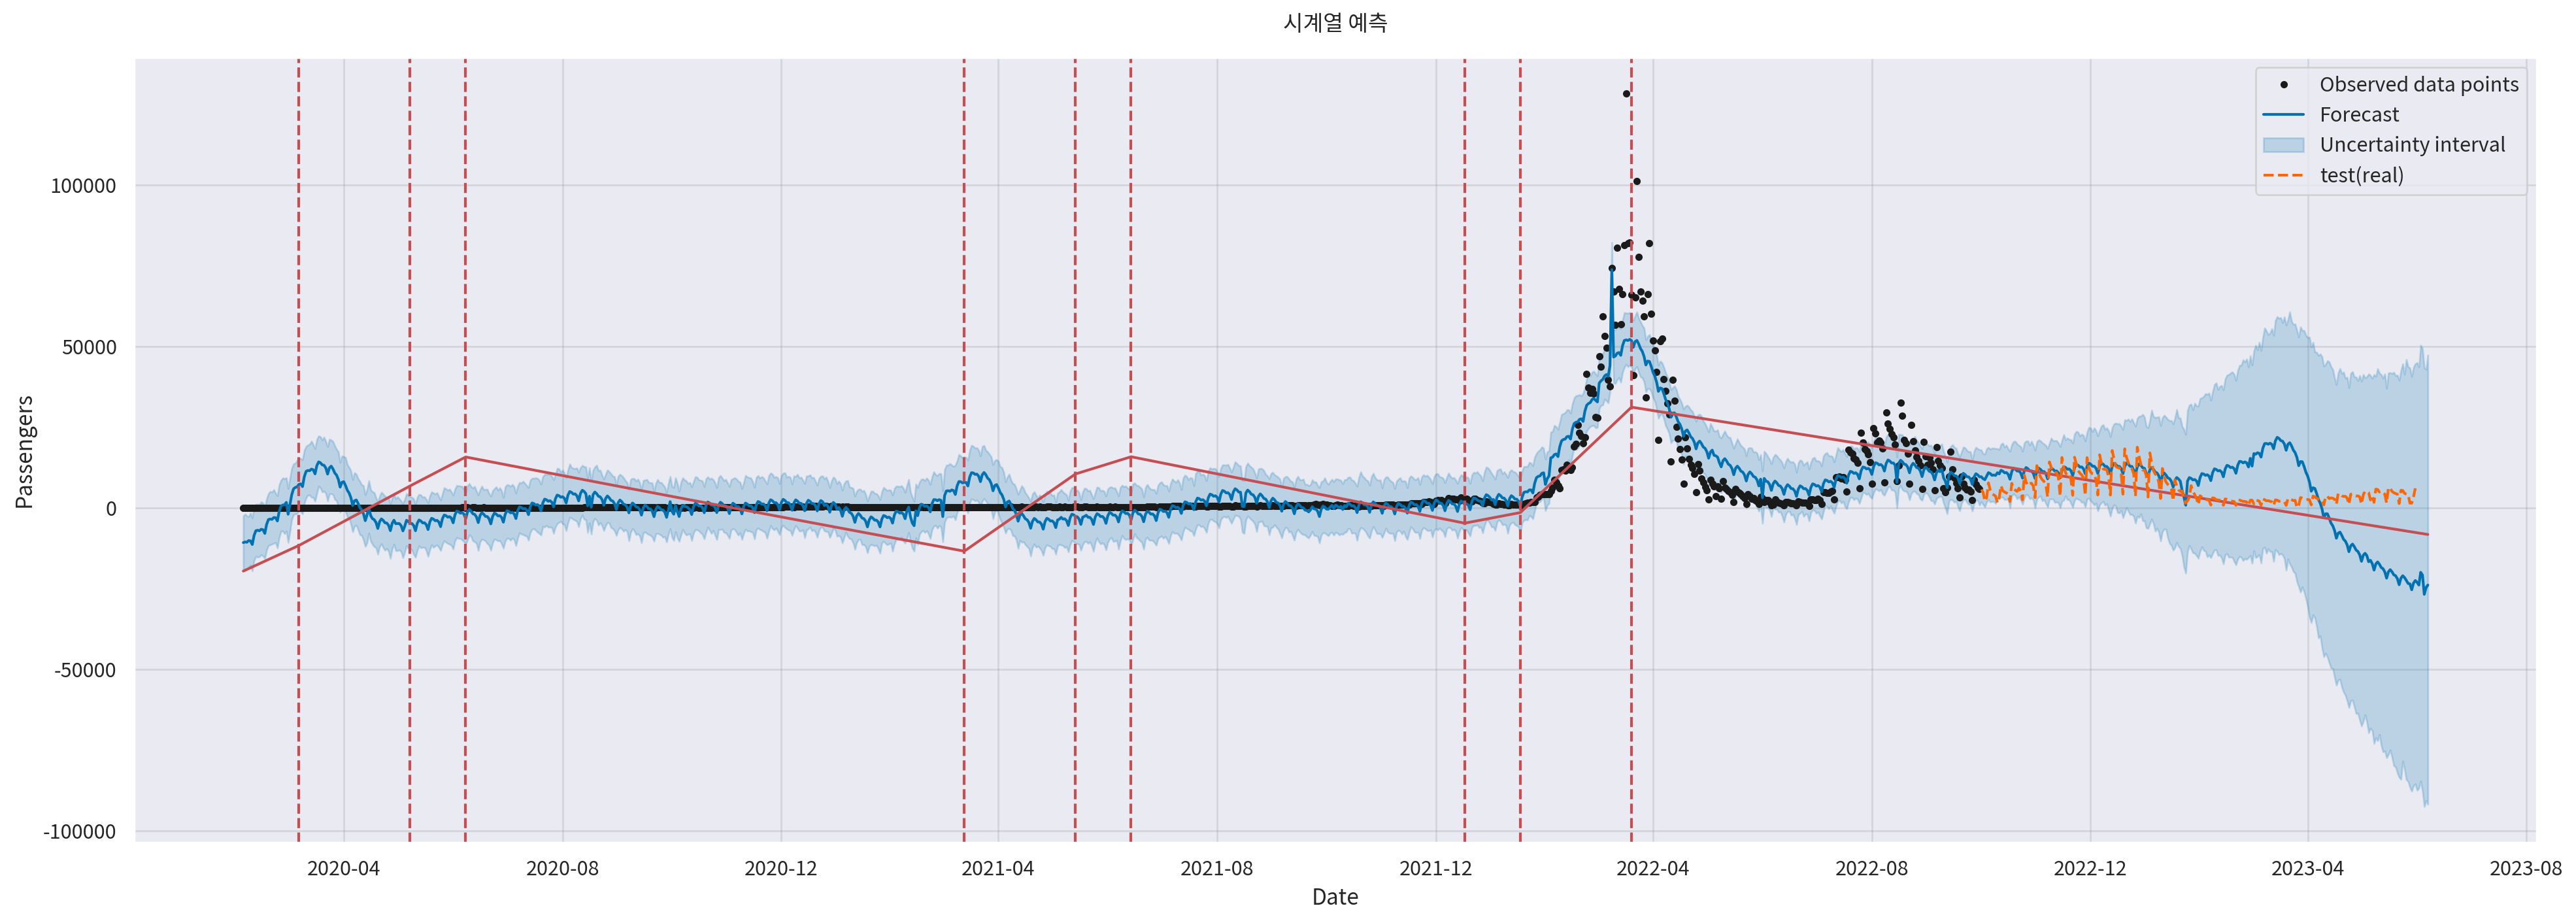

In [19]:
fig = best_model.plot(forecast, figsize=(20, 7), xlabel='Date', ylabel='Passengers', uncertainty=True)
ax = fig.gca()
add_changepoints_to_plot(ax, best_model, forecast)
ax.set_title("시계열 예측")
# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(data=test, x='ds', y='y', ax=ax, color='#ff6600', linestyle="--", label='test(real)')
plt.show()
plt.close()

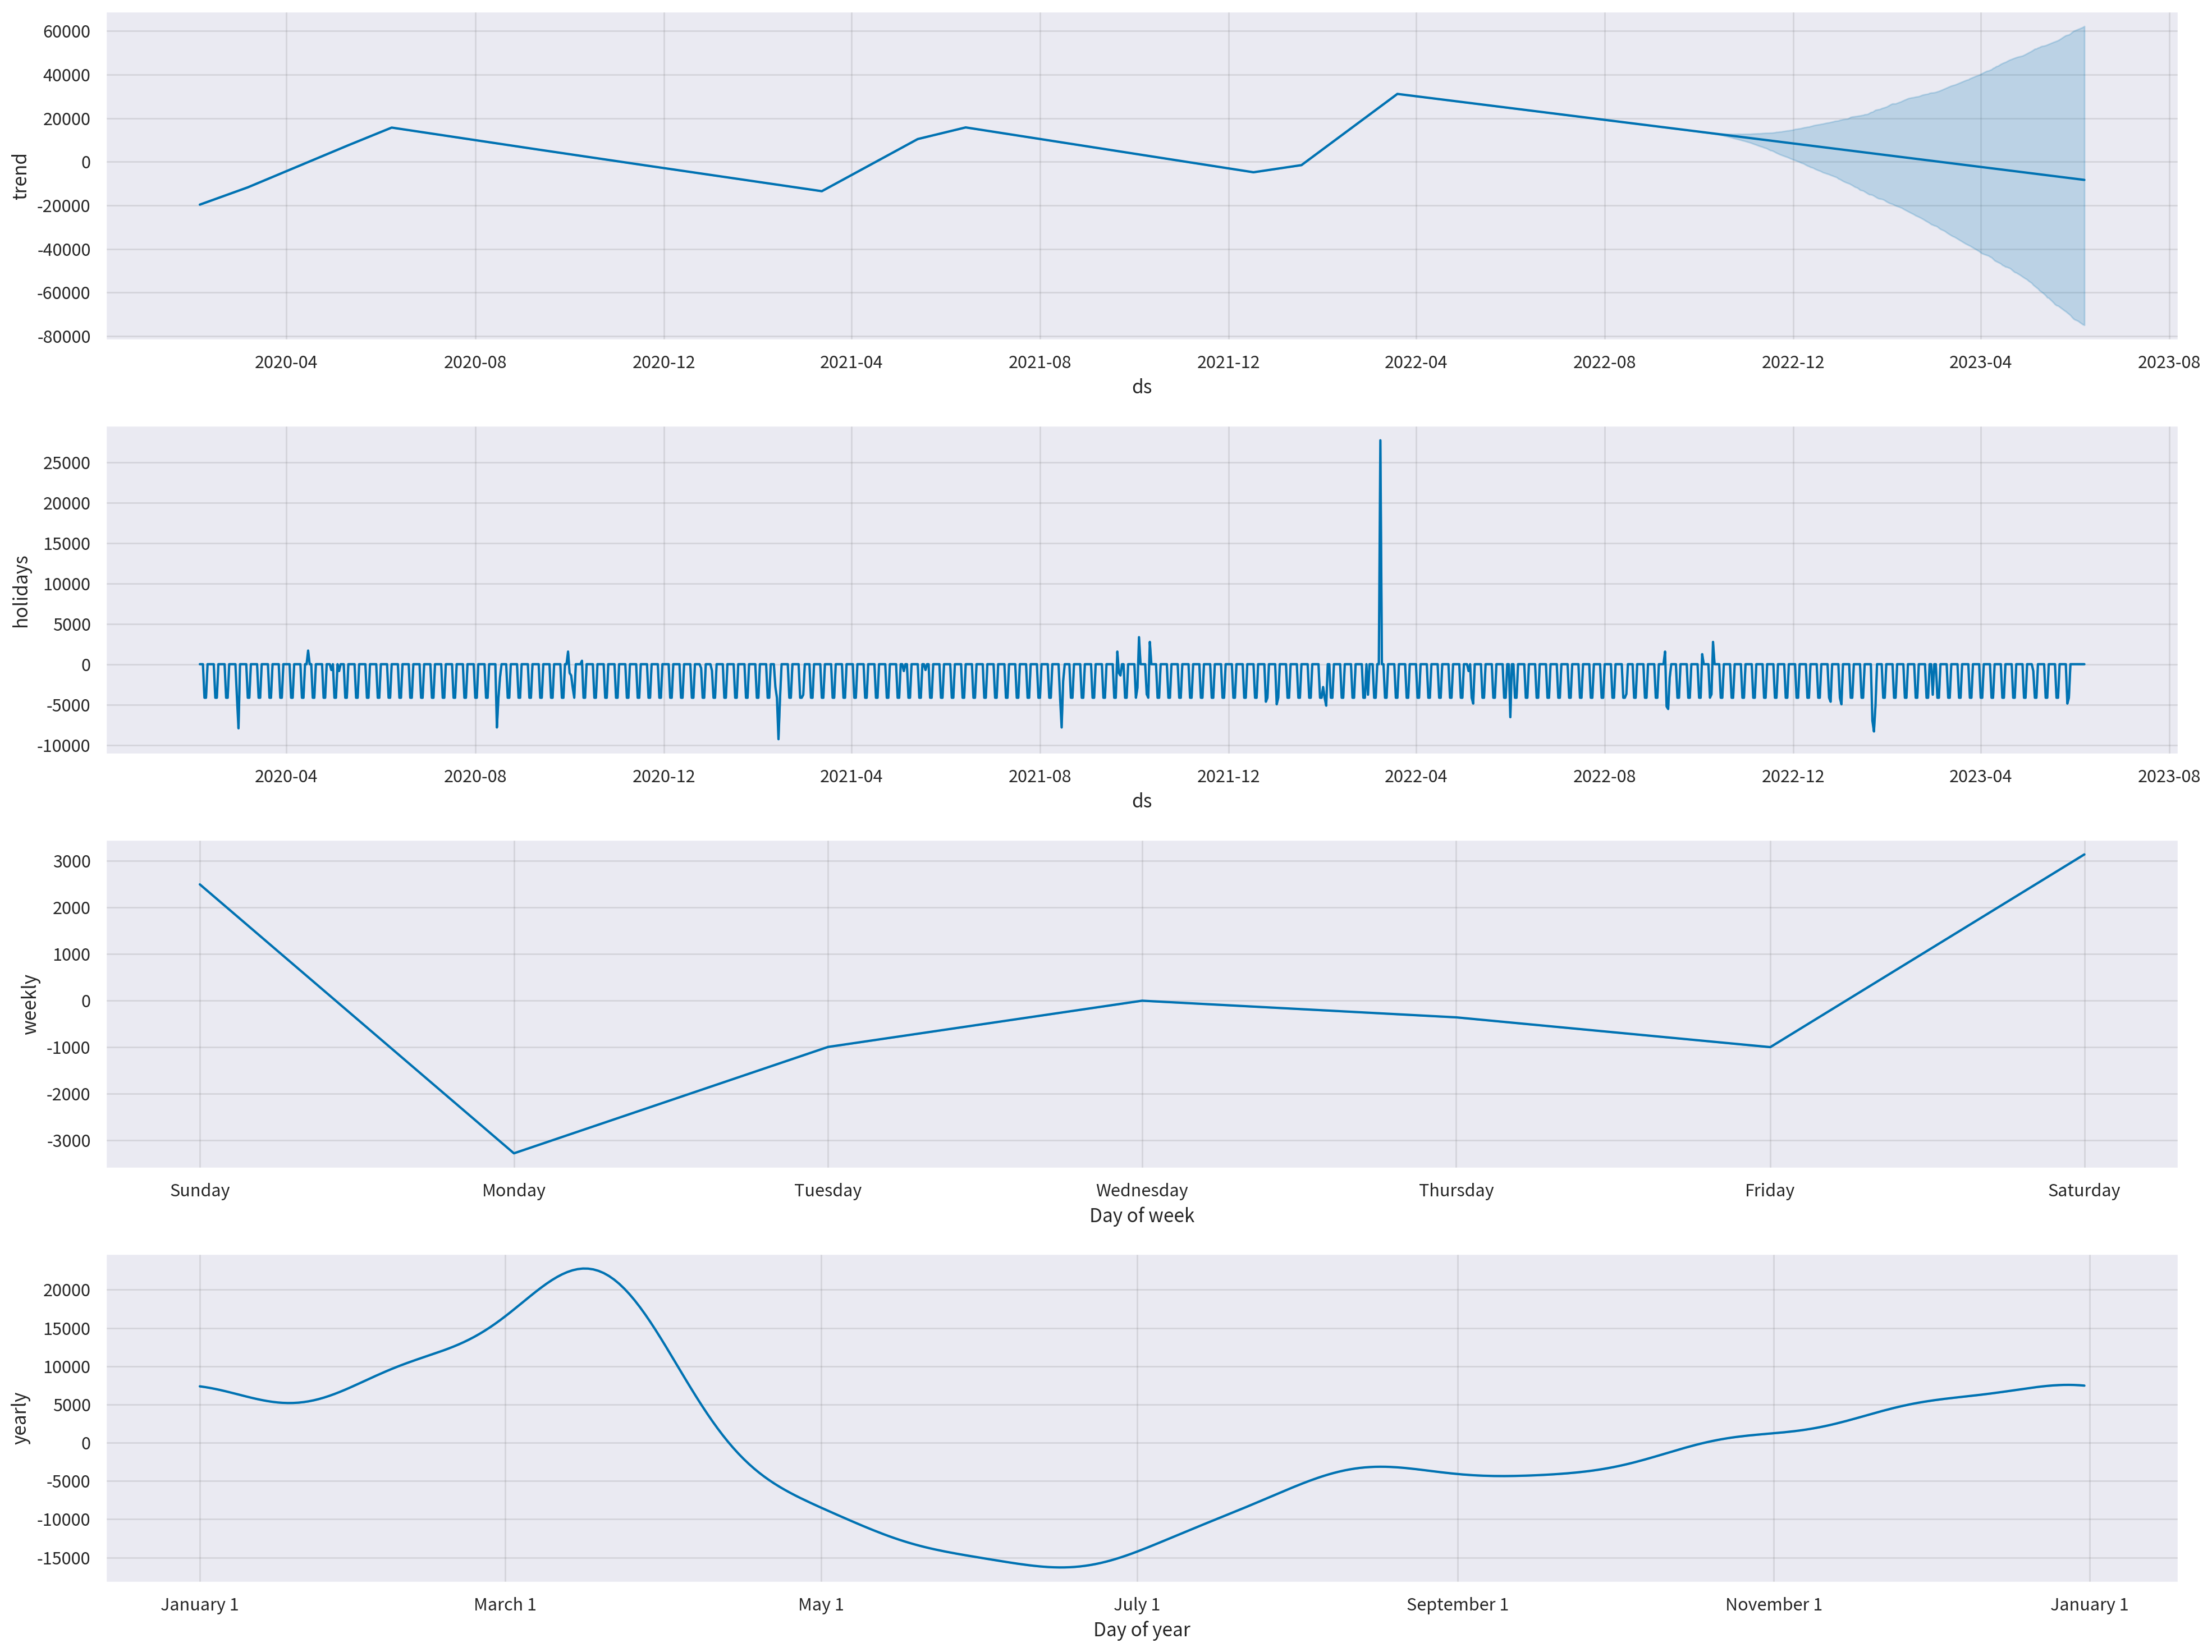

In [20]:
fig = best_model.plot_components(forecast, figsize=(20, 15))
ax = fig.gca()
plt.show()
plt.close()